# Reactive vs Conservative — 1000 vehicles

500 AEVs + 500 HEVs; 3 dedicated AEV stations × 50 plugs. Two four-hour charging-demand scenarios, 10 paired seeds each. No passenger service or learning.

**Reactive** reads the original `current` runs. **Conservative** reads the new `real_conservative` runs with binding plug reservations and consistent physical timing. The earlier `conservative` implementation is not included in this comparison. Internal policy IDs stay unchanged; only plot labels use Reactive / Conservative.

AEV charging trips in the new mode reach the station coordinate rather than stopping at a zone boundary. Thus the comparison includes an execution-semantics correction. Both source experiments are preserved; matched configurations and per-seed initial-state hashes are checked below. Comparison outputs are saved separately. Zero observed queues test the deterministic implementation on these runs, not arbitrary uncertain travel or uncontrolled arrivals.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
RESULTS = ROOT / 'results/nyc_real_conservative_1000_20260919'
SOURCES = {
    'current': ROOT / 'results/nyc_charging_rollout_1000',
    'real_conservative': RESULTS,
}
OUTPUT = RESULTS / 'comparison_reactive_real_conservative'
FIGURES = OUTPUT / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
policies = ['current', 'real_conservative']
labels = {'current': 'Reactive', 'real_conservative': 'Conservative'}
manifest = json.loads((RESULTS / 'manifest.json').read_text())
scenarios = manifest['config']['scenarios']
seeds = manifest['config']['seeds']
frames = []
for policy, source in SOURCES.items():
    source_manifest = json.loads((source / 'manifest.json').read_text())
    for key in ('vehicles', 'hev', 'centers', 'hours', 'seeds', 'scenarios'):
        assert source_manifest['config'][key] == manifest['config'][key], (policy, key)
    frame = pd.DataFrame(json.loads((source / 'summary.json').read_text()))
    frames.append(frame.loc[frame.policy.eq(policy)].copy())
raw = pd.concat(frames, ignore_index=True)
aev = raw.loc[raw.fleet.eq('AEV')].copy()
expected = {(s, k, p) for s in scenarios for k in seeds for p in policies}
assert set(aev[['scenario','seed','policy']].itertuples(index=False, name=None)) == expected
assert not aev.duplicated(['scenario','seed','policy']).any()
assert aev.groupby(['scenario','seed']).initial_state_sha256.nunique().eq(1).all()
print(f'{len(aev)} runs, {len(seeds)} paired seeds per scenario')
display(pd.DataFrame([manifest['config']]))
display(pd.DataFrame([{'policy_id': p, 'plot_label': labels[p], 'source': str(SOURCES[p])} for p in policies]))
(OUTPUT / 'sources.json').write_text(json.dumps({p: {'label': labels[p], 'source': str(SOURCES[p])} for p in policies}, indent=2))

40 runs, 10 paired seeds per scenario


,vehicles,hev,centers,hours,seeds,scenarios,policies,output_dir
0,1000,500,3,4.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]","[burst, staggered]","[conservative, real_conservative]",results/nyc_real_conservative_1000_20260919


,policy_id,plot_label,source
0,current,Reactive,/Users/seinzhou/Desktop/icaps/results/nyc_char...
1,real_conservative,Conservative,/Users/seinzhou/Desktop/icaps/results/nyc_real...


276

## Independent event and reservation validation
Queue length includes only physically arrived AEVs waiting at dedicated stations. It excludes HEVs, pending dispatch and inbound vehicles. We check both queue-entry events and arrival/start timestamps; assertions also verify predictions, completions and historical per-plug non-overlap. Incomplete charging sessions remain explicitly censored at the four-hour horizon.

In [2]:
def load_lines(path):
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
validation=[]
series=[]
for scenario in scenarios:
    for seed in seeds:
        for policy in policies:
            folder = SOURCES[policy] / f'{scenario}_seed{seed}_{policy}'
            sessions = pd.DataFrame(load_lines(folder/'sessions.jsonl'))
            ss = sessions.loc[sessions.fleet.eq('AEV')].copy()
            events = load_lines(folder/'events.jsonl')
            aev_ids = set(ss.vehicle_id)
            arrivals = ss.loc[ss.arrival_epoch.notna() & ~ss.initial_charging]
            new_arrivals = arrivals.loc[~arrivals.initial_committed]
            queue_entries = sum(e['event']=='queue_enter' and e['vehicle_id'] in aev_ids for e in events)
            native = (arrivals.start_epoch - arrivals.arrival_epoch) * .5
            row = dict(scenario=scenario, seed=seed, policy=policy,
                       arrivals=len(arrivals), newly_assigned_arrivals=len(new_arrivals),
                       queued_arrivals=int(arrivals.ever_queued.sum()), queue_entries=queue_entries,
                       max_actual_wait_minutes=float(native.max()),
                       pending_inbound=int((ss.assignment_epoch.notna() & ss.arrival_epoch.isna()).sum()),
                       pending_dispatch=int(ss.assignment_epoch.isna().sum()))
            if policy == 'real_conservative':
                audit = json.loads((folder/'reservation_audit.json').read_text())
                reservations = {r['vehicle_id']:r for r in audit['reservations']}
                assert len(reservations)==len(audit['reservations'])  # one-charge workload
                assert queue_entries==0 and not arrivals.ever_queued.any()
                assert arrivals.start_epoch.notna().all() and native.eq(0).all()
                assert len(arrivals)>0
                admissions = load_lines(folder/'admissions.jsonl')
                for admission in admissions:
                    reservation = reservations[admission['vehicle_id']]
                    assert admission['expected_arrival']==reservation['arrival']
                    assert admission['expected_completion']==reservation['end']
                for session in ss.to_dict('records'):
                    if pd.isna(session['assignment_epoch']): continue
                    reservation = reservations[session['vehicle_id']]
                    if not session['initial_charging'] and pd.notna(session['arrival_epoch']):
                        assert session['arrival_epoch']==reservation['arrival']==session['start_epoch']
                    if pd.notna(session['completion_epoch']):
                        assert session['completion_epoch']==reservation['end']
                calendar = pd.DataFrame(audit['reservations'])
                for _, group in calendar.groupby(['station_id','plug_index']):
                    group = group.sort_values('start')
                    assert np.all(group.start.to_numpy()[1:] >= group.end.to_numpy()[:-1])
                assert audit['invariant_checks'] >= manifest['config']['hours']*120
                physical_stations = pd.DataFrame(load_lines(folder/'stations.jsonl'))
                assert physical_stations.queue.eq(0).all()
                assert physical_stations.occupied.le(physical_stations.capacity).all()
                row['binding_reservations'] = len(reservations)
                row['invariant_checks'] = audit['invariant_checks']
            validation.append(row)
            frame = pd.DataFrame(load_lines(folder/'timeseries.jsonl'))
            series.append(frame.loc[frame.fleet.eq('AEV')].assign(scenario=scenario,seed=seed,policy=policy))
validation = pd.DataFrame(validation)
validation.to_json(OUTPUT/'validation.json',orient='records',indent=2)
display(validation.groupby(['scenario','policy']).agg(
    runs=('seed','size'), arrivals=('arrivals','sum'),
    newly_assigned_arrivals=('newly_assigned_arrivals','sum'),
    queued_arrivals=('queued_arrivals','sum'), queue_entries=('queue_entries','sum'),
    max_wait_minutes=('max_actual_wait_minutes','max'), pending_inbound=('pending_inbound','sum')))
print('real_conservative: all observed AEV arrivals start immediately; all checked reservations are honored.')
# Background HEV behavior must be paired and unchanged.
hev = raw.loc[raw.fleet.eq('HEV')].pivot(index=['scenario','seed'], columns='policy',
    values=['completion_count','mean_queue_length','utilization'])
for metric in ('completion_count','mean_queue_length','utilization'):
    np.testing.assert_allclose(hev[metric]['current'], hev[metric]['real_conservative'], atol=1e-12)

runs  arrivals  newly_assigned_arrivals  \
scenario  policy                                                       
burst     current              10      4236                     4086   
          real_conservative    10      4236                     4086   
staggered current              10      4236                     4086   
          real_conservative    10      4236                     4086   

                             queued_arrivals  queue_entries  max_wait_minutes  \
scenario  policy                                                                
burst     current                       3027           3027             227.0   
          real_conservative                0              0               0.0   
staggered current                       2736           2736              47.0   
          real_conservative                0              0               0.0   

                             pending_inbound  
scenario  policy                              
burst     current                          0  
          real_conservative                0  
staggered current                          0  
          real_conservative                0

real_conservative: all observed AEV arrivals start immediately; all checked reservations are honored.


In [3]:
metrics = ['utilization','mean_occupied_slots','mean_queue_length','max_queue_length',
           'mean_wait_minutes_all_arrivals','native_mean_wait_minutes_started',
           'completion_count','dispatch_delay_lower_bound_minutes',
           'pending_dispatch_count','pending_inbound_count','pending_charging_count']
means = aev.groupby(['scenario','policy'])[metrics].mean()
display(means.round(3))
means.reset_index().to_json(OUTPUT/'analysis_means_AEV.json',orient='records',indent=2)

utilization  mean_occupied_slots  \
scenario  policy                                                
burst     current                  0.894              134.126   
          real_conservative        0.907              136.004   
staggered current                  0.874              131.045   
          real_conservative        0.866              129.912   

                             mean_queue_length  max_queue_length  \
scenario  policy                                                   
burst     current                      126.302             273.8   
          real_conservative              0.000               0.0   
staggered current                        7.042              26.4   
          real_conservative              0.000               0.0   

                             mean_wait_minutes_all_arrivals  \
scenario  policy                                              
burst     current                                    71.538   
          real_conservative                           0.000   
staggered current                                     3.988   
          real_conservative                           0.000   

                             native_mean_wait_minutes_started  \
scenario  policy                                                
burst     current                                      71.538   
          real_conservative                             0.000   
staggered current                                       3.988   
          real_conservative                             0.000   

                             completion_count  \
scenario  policy                                
burst     current                       409.7   
          real_conservative             408.4   
staggered current                       359.1   
          real_conservative             357.1   

                             dispatch_delay_lower_bound_minutes  \
scenario  policy                                                  
burst     current                                        22.272   
          real_conservative                              82.017   
staggered current                                        38.931   
          real_conservative                              44.584   

                             pending_dispatch_count  pending_inbound_count  \
scenario  policy                                                             
burst     current                              46.4                    0.0   
          real_conservative                    46.4                    0.0   
staggered current                              46.4                    0.0   
          real_conservative                    46.4                    0.0   

                             pending_charging_count  
scenario  policy                                     
burst     current                              43.9  
          real_conservative                    45.2  
staggered current                              94.5  
          real_conservative                    96.5

## Station trajectories
Lines are equal-seed means; shading is the 95% Student-t confidence interval of the mean (n=10). Occupancy and queue length are sampled after action execution, before the next charging update. Actual completion events occur at the update boundary. Zero physical queue does not mean zero delay before dispatch.

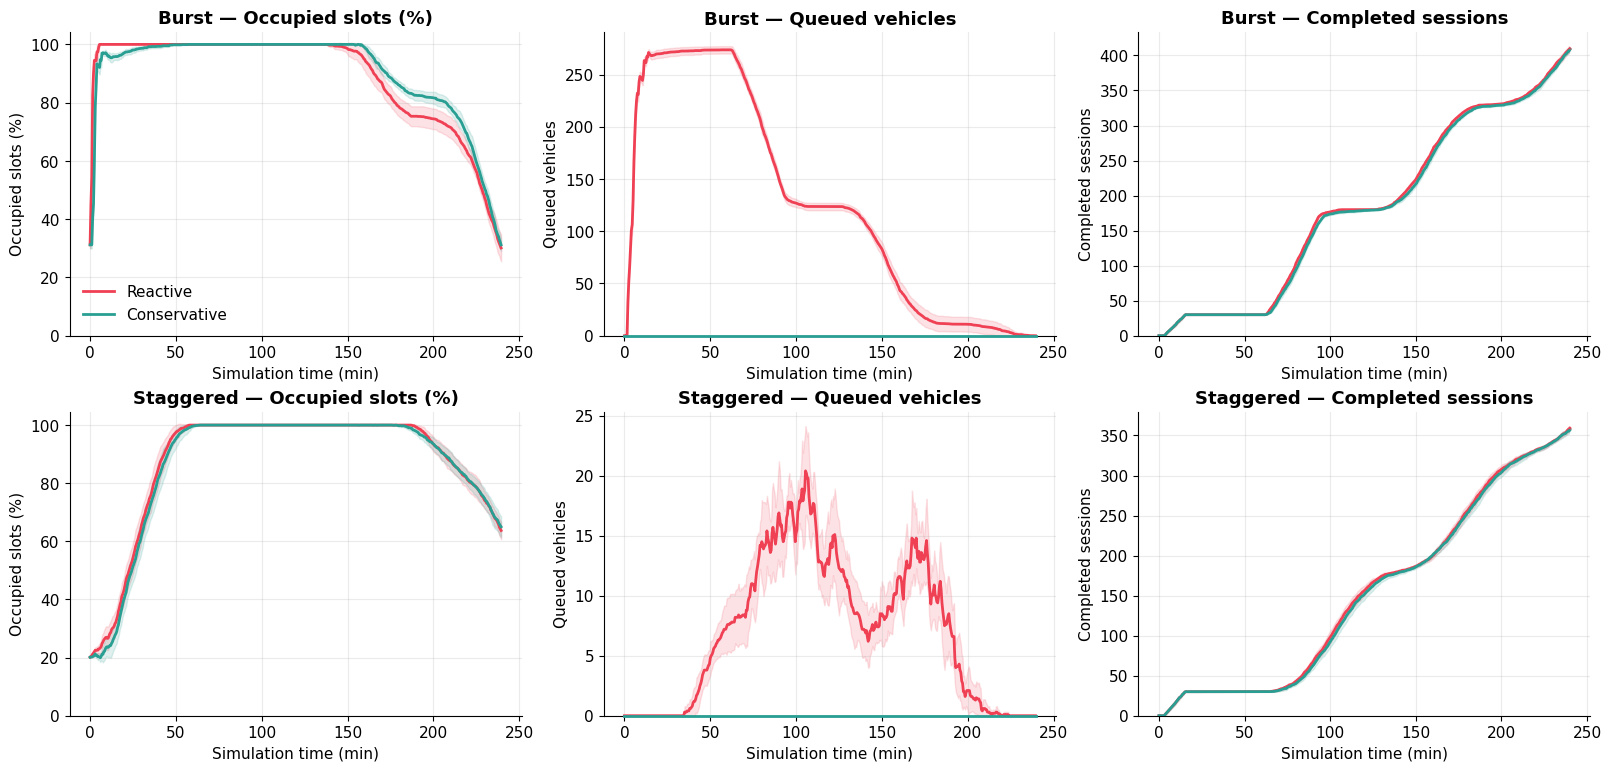

In [6]:
plt.rcParams.update({'font.size':11, 'axes.titlesize':13, 'axes.titleweight':'bold',
                     'axes.spines.top':False, 'axes.spines.right':False})
colors = {'current':'#EF4054','real_conservative':'#299F93'}
# Display labels are defined above; internal policy IDs are retained.
ts = pd.concat(series,ignore_index=True)
ts['utilization_percent'] = 100*ts.occupied/ts.capacity
fig, axes = plt.subplots(2,3,figsize=(16,7.6),constrained_layout=True)
for row, scenario in enumerate(scenarios):
    for col, (metric, ylabel) in enumerate([('utilization_percent','Occupied slots (%)'),
                                           ('queue','Queued vehicles'),('completed','Completed sessions')]):
        ax = axes[row,col]
        for policy in policies:
            subset = ts.loc[ts.scenario.eq(scenario)&ts.policy.eq(policy)]
            curve = subset.groupby('minutes')[metric].agg(['mean','std','count'])
            ci = t.ppf(.975,curve['count']-1)*curve['std']/np.sqrt(curve['count'])
            ax.plot(curve.index,curve['mean'],color=colors[policy],label=labels[policy],lw=2,
                    zorder=3,clip_on=False if metric=='queue' else True)
            ax.fill_between(curve.index,np.maximum(0,curve['mean']-ci),curve['mean']+ci,
                            color=colors[policy],alpha=.15)
            if metric=='completed':
                endpoint = aev.loc[aev.scenario.eq(scenario)&aev.policy.eq(policy),'completion_count'].mean()
                ax.plot([curve.index[-1],manifest['config']['hours']*60],
                        [curve['mean'].iloc[-1],endpoint],color=colors[policy],lw=2)
        ax.set(title=f'{scenario.title()} — {ylabel}',xlabel='Simulation time (min)',ylabel=ylabel)
        ax.set_ylim(bottom=0)
        ax.grid(alpha=.25)
axes[0,0].legend(frameon=False)
fig.savefig(FIGURES/'charge_mode_real_conservative.png',dpi=300,bbox_inches='tight')
fig.savefig(FIGURES/'charge_mode_real_conservative.pdf',bbox_inches='tight')
plt.show()

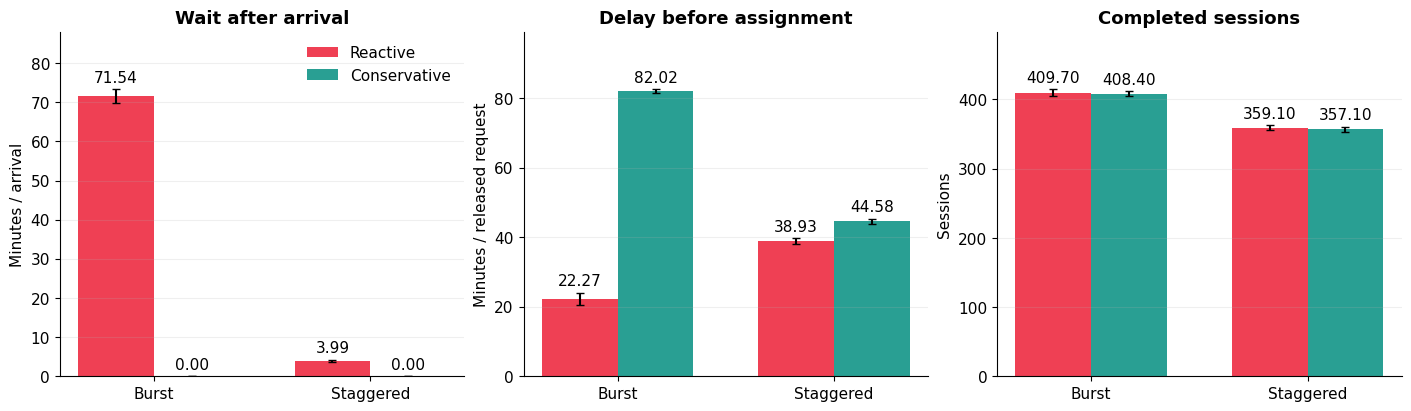

In [5]:
fig, axes = plt.subplots(1,3,figsize=(14,4),constrained_layout=True)
for ax, metric, title, ylabel in zip(axes,
    ['mean_wait_minutes_all_arrivals','dispatch_delay_lower_bound_minutes','completion_count'],
    ['Wait after arrival','Delay before assignment','Completed sessions'],
    ['Minutes / arrival','Minutes / released request','Sessions']):
    x=np.arange(len(scenarios))
    for i,policy in enumerate(policies):
        samples=[aev.loc[aev.scenario.eq(s)&aev.policy.eq(policy),metric] for s in scenarios]
        mean=np.array([s.mean() for s in samples])
        ci=np.array([t.ppf(.975,len(s)-1)*s.std()/np.sqrt(len(s)) for s in samples])
        bars=ax.bar(x+(i-.5)*.35,mean,.35,yerr=ci,capsize=3,label=labels[policy],color=colors[policy])
        ax.bar_label(bars,fmt='%.2f',padding=3)
    ax.set(title=title,ylabel=ylabel,xticks=x,xticklabels=[s.title() for s in scenarios])
    ax.margins(y=.2)
    ax.grid(axis='y',alpha=.2)
axes[0].legend(frameon=False)
fig.savefig(FIGURES/'waiting_and_completion.png',dpi=240,bbox_inches='tight')
plt.show()